# QELM vs QK

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import myQMLfunctions as myQML

In [8]:
rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)

In [9]:
print(rho_training.shape)
print(rho_training)
print('\n')
print(rho_training[0])

(100, 2, 2)
[[[ 0.67425712+0.j         -0.0574754 +0.39262473j]
  [-0.0574754 -0.39262473j  0.32574288+0.j        ]]

 [[ 0.11009252+0.j         -0.23079852-0.04646777j]
  [-0.23079852+0.04646777j  0.88990748+0.j        ]]

 [[ 0.15680532+0.j         -0.15738583-0.26339012j]
  [-0.15738583+0.26339012j  0.84319468+0.j        ]]

 [[ 0.1173673 +0.j         -0.16917144+0.16839185j]
  [-0.16917144-0.16839185j  0.8826327 +0.j        ]]

 [[ 0.37380932+0.j         -0.34057805+0.23837726j]
  [-0.34057805-0.23837726j  0.62619068+0.j        ]]

 [[ 0.33116129+0.j         -0.12991631+0.02140576j]
  [-0.12991631-0.02140576j  0.66883871+0.j        ]]

 [[ 0.56319954+0.j          0.27587709-0.14817046j]
  [ 0.27587709+0.14817046j  0.43680046+0.j        ]]

 [[ 0.51480823+0.j         -0.08916328-0.4503242j ]
  [-0.08916328+0.4503242j   0.48519177+0.j        ]]

 [[ 0.72077525+0.j         -0.40550639+0.12592758j]
  [-0.40550639-0.12592758j  0.27922475+0.j        ]]

 [[ 0.61365533+0.j          0.1506

In [10]:
rho = myQML.generate_random_density_matrix(2)
print(rho)
print(np.trace(rho))

[[0.43634279-9.16035628e-20j 0.38193668+1.38027274e-01j]
 [0.38193668-1.38027274e-01j 0.56365721+9.16035628e-20j]]
(0.9999999999999999+0j)


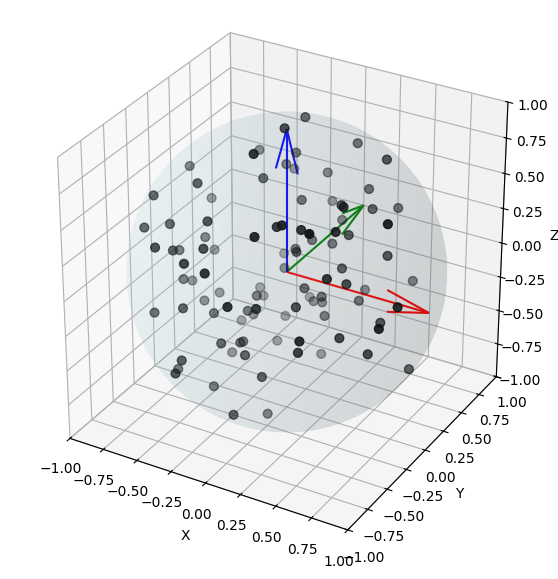

In [11]:
bloch_points_1 = [myQML.density_to_bloch(rho) for rho in rho_training]
myQML.plot_bloch_sphere(bloch_points_1)

In [12]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()